In [63]:
import tifffile as tf 
import zarr 
# import pillow
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import json
import numpy as np
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import xgboost as xgb
from scipy.spatial import ConvexHull, Delaunay
import pickle
import os
import time
# import torch
# import torch.nn as nn
from tqdm.auto import tqdm
import numpy as np
import tifffile as tf
import zarr
import dask.array as da
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import cellcutter
import cellcutter.cli
from numcodecs import Blosc
# import logging
# logger = logging.getLogger()
# logger.setLevel(logging.DEBUG)
# logging.debug("test")

In [64]:
reference_df = pd.read_csv('/Users/swarchol/Downloads/reference/df (1).csv')

In [4]:
reference_df

,CellID,DNA,DNA (2),DNA (3),CD3,CD45RO,DNA (4),Pan-cytokeratin,Aortic smooth muscle actin,DNA (5),...,Sample,Condition,Replicate,emb1,emb2,cluster_2d,UMAP_X,UMAP_Y,kmeans,hdbscan
0,47,15160.563636,46937.436364,42258.036364,0.235838,0.446541,24461.163636,0.270726,0.175902,29225.363636,...,WD-76845-097,CRC,1,8.872235,19.100700,-1,16034.611561,20497.943539,3,3
1,49,11740.781250,50723.343750,37632.750000,0.227137,0.584889,20075.703125,0.307917,0.174437,23681.062500,...,WD-76845-097,CRC,1,8.379912,20.137026,48,15764.366949,21180.248327,3,3
2,51,9565.513514,35690.567568,27032.162162,0.200757,0.436587,14392.621622,0.223040,0.162788,16623.810811,...,WD-76845-097,CRC,1,8.799885,19.362713,-1,15994.897394,20670.449801,3,3
3,52,7308.113636,24641.750000,19214.886364,0.228204,0.662923,9205.522727,0.272994,0.207245,11968.636364,...,WD-76845-097,CRC,1,8.504932,20.219538,48,15832.992590,21234.573253,3,3
4,53,19249.623188,57667.202899,53509.811594,0.261224,0.704192,30691.275362,0.295741,0.296045,35399.927536,...,WD-76845-097,CRC,1,8.576233,20.350970,48,15872.130942,21321.106528,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933248,1242746,18694.276596,18604.936170,17079.659574,0.248739,0.205520,6982.680851,0.136490,0.334573,9554.489362,...,WD-76845-097,CRC,1,18.186203,2.827556,72,21147.209738,9783.897947,2,9
933249,1242748,31240.095238,34545.301587,32678.349206,0.361773,0.381520,12513.238095,0.219673,0.126889,17597.158730,...,WD-76845-097,CRC,1,11.654654,19.720820,-1,17561.929764,20906.223217,3,3
933250,1242751,45004.015873,47513.269841,44139.714286,0.229271,0.467404,16901.253968,0.152905,0.283555,20190.285714,...,WD-76845-097,CRC,1,18.262630,3.071928,72,21189.161841,9944.789517,11,9
933251,1242753,33568.983607,35640.344262,31911.131148,0.233328,0.515689,12369.524590,0.134693,0.331565,15530.245902,...,WD-76845-097,CRC,1,19.307392,3.061911,72,21762.649778,9938.194640,2,9


In [65]:
new_df = pd.read_csv('/Users/swarchol/Research/seal/data/dan2/updated_best_kmeans.csv')


In [66]:
new_df.shape
new_df.columns
new_df
# drop column 'IN'

,CellID,DNA1,AF1,CD31,Ki67,CD68,CD163,CD20,CD4,CD8a,...,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,UMAP_X,UMAP_Y,kmeans_cluster,kmeans
0,1,1967.393897,1483.656033,465.804438,677.133148,182.382802,468.564494,629.219140,120.654646,173.877947,...,31.354913,29.315962,0.354722,0.969086,0.751042,-0.288126,42608.985199,38510.445813,9,9
1,2,2040.625483,1482.889961,424.957529,743.833977,229.916988,1156.550193,734.996139,128.191120,171.461390,...,27.810896,23.760244,0.519698,0.966418,0.711538,-0.554064,42574.929227,32154.174037,9,9
2,3,1942.463788,1499.770195,441.263231,718.445682,307.281337,1575.454039,703.658774,173.001393,165.869081,...,35.237328,25.987645,0.675344,0.974220,0.725253,-0.633757,7174.332665,13312.043350,3,3
3,4,2461.936170,1762.250000,529.908245,896.590426,846.747340,3580.190160,908.356383,142.162234,156.525266,...,35.798416,26.837437,0.661798,0.966581,0.696296,-1.141488,37075.397488,31230.497749,7,7
4,5,3514.763473,3447.875749,566.571856,981.797904,255.820359,1280.887725,1166.537425,66.851796,148.896707,...,33.921502,25.172952,0.670296,0.973761,0.734066,1.300686,39415.568065,38237.789133,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1031667,1031774,2381.862471,1510.460373,1229.756410,560.231935,262.540793,1028.489510,556.993007,304.201632,173.096737,...,38.781651,28.281511,0.684248,0.972789,0.722222,-0.632073,13706.023005,11558.085938,3,3
1031668,1031775,2174.084760,578.123288,342.340753,374.746575,459.856164,1938.887842,393.556507,348.191781,171.476884,...,52.446693,28.523412,0.839179,0.970906,0.778667,-0.184416,50795.594431,13596.918582,10,10
1031669,1031777,1834.338920,6106.471136,78.122905,68.277467,120.895717,1264.931099,127.493482,47.109870,32.057728,...,28.112283,24.703231,0.477311,0.947090,0.764957,-1.213656,22535.362108,5674.140073,6,6
1031670,1031778,2097.875874,8013.501748,80.195804,53.980769,78.900350,1426.033217,142.846154,5.223776,9.531469,...,29.003433,25.726677,0.461728,0.942339,0.758621,-0.383420,23417.451185,7055.345416,6,6


In [ ]:
# drop column 'IN'
new_df = new_df.drop(columns=['kmeans_cluster'])





In [68]:
# rename cluster 'kmeans' to 'cluster'
new_df = new_df.rename(columns={'kmeans': 'cluster'})


In [69]:
new_df.to_csv('/Users/swarchol/Downloads/melanoma/df.csv', index=False)
new_df.to_parquet('/Users/swarchol/Downloads/melanoma/df.parquet')

In [12]:
small_reference = pd.read_csv('/Users/swarchol/Downloads/reference/small (1).csv')
small_reference

,CellID,X_centroid,Y_centroid,cluster_2d,UMAP_X,UMAP_Y,kmeans,hdbscan
0,47,9421.436364,1228.290909,-1,16034.611561,20497.943539,3,3
1,49,9460.328125,1233.937500,48,15764.366949,21180.248327,3,3
2,51,9475.702703,1235.189189,-1,15994.897394,20670.449801,3,3
3,52,9507.795455,1234.886364,48,15832.992590,21234.573253,3,3
4,53,9513.478261,1239.521739,48,15872.130942,21321.106528,3,3
...,...,...,...,...,...,...,...,...
933248,1242746,7316.808511,26816.085106,72,21147.209738,9783.897947,2,9
933249,1242748,7084.936508,26818.603175,-1,17561.929764,20906.223217,3,3
933250,1242751,6961.650794,26820.888889,72,21189.161841,9944.789517,11,9
933251,1242753,6942.491803,26821.442623,72,21762.649778,9938.194640,2,9


In [70]:
# CellID	X_centroid	Y_centroid	cluster_2d	UMAP_X	UMAP_Y	kmeans
new_df[['CellID', 'X_centroid', 'Y_centroid', 'UMAP_X', 'UMAP_Y', 'cluster']].to_csv('/Users/swarchol/Downloads/melanoma/small.csv', index=False)

In [45]:
new_df.columns
feature_columns = ['AF1', 'CD31', 'Ki67', 'CD68', 'CD163', 'CD20', 'CD4',
       'CD8a', 'CD11c', 'PDL1', 'CD3e', 'ECAD', 'PD1', 'FOXP3', 'CD45',
       'SOX10','pH3']

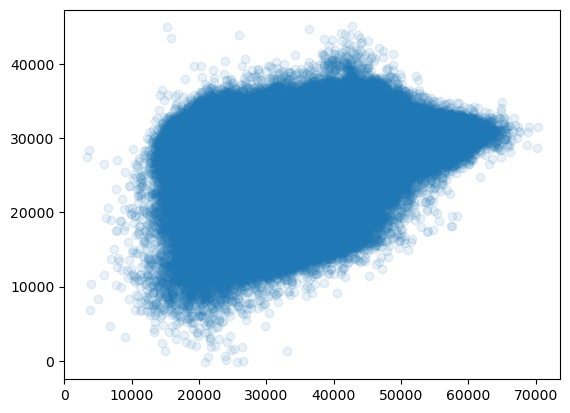

In [48]:
feature_data = new_df[feature_columns].to_numpy()
# feature_data = np.nan_to_num(feature_data)
regressor = xgb.XGBRegressor(
                 n_estimators=200,
                 max_depth=6)

regressor.fit(feature_data, new_df[['UMAP_X','UMAP_Y']])
xgb_preds = regressor.predict(feature_data)
plt.scatter(xgb_preds[:,0], xgb_preds[:,1], alpha=0.1)
explainer = shap.Explainer(regressor)
shap_values = explainer(feature_data)







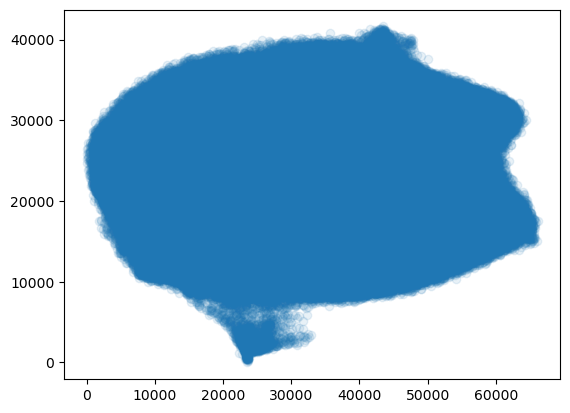

In [47]:
plt.scatter(new_df['UMAP_X'], new_df['UMAP_Y'], alpha=0.1)

In [49]:
shap_values.values.shape

(1031672, 17, 2)

In [53]:
abs_shap = np.abs(shap_values.values).sum(axis=2)
# # shap_values = np.abs(shap_values.values)

In [55]:
# # shap_values = np.abs(shap_values.values)
alphabetical_features = sorted(feature_columns)
indices = [feature_columns.index(feature) for feature in alphabetical_features]
# indices
alphabetical_shap_values = abs_shap[:, indices]
# # np.save('/Users/swarchol/Downloads/melanoma/astro.shap.npy', alphabetical_shap_values)
# # create a df
alphabetical_shap_values_df = pd.DataFrame(alphabetical_shap_values, columns=alphabetical_features)
alphabetical_shap_values_df.head()

,AF1,CD11c,CD163,CD20,CD31,CD3e,CD4,CD45,CD68,CD8a,ECAD,FOXP3,Ki67,PD1,PDL1,SOX10,pH3
0,10023.039062,1028.428833,1230.605957,2452.891113,3782.397705,218.828094,3783.373047,1915.816528,490.688171,856.062256,10337.785156,849.460693,285.101410,2100.748535,1262.633301,6668.358398,2934.539307
1,11706.113281,880.887085,4180.295898,5108.943359,2394.306641,1067.960571,3010.131836,2764.242676,1311.601440,1499.475342,9601.240234,664.953491,208.797256,1937.047852,653.415588,3829.333008,2602.962891
2,8284.587891,1776.594971,4968.531738,5309.305664,1879.489258,1079.724609,785.305298,6757.601562,166.386856,373.364319,12417.401367,506.100769,521.393799,849.305054,612.403442,4820.634277,2201.771484
3,12212.032227,902.260681,5879.700195,6136.849121,3551.138672,267.272156,2914.777344,4774.627441,1685.010864,364.115265,9984.512695,1480.345215,606.030396,2530.663574,1387.609497,3836.957031,2636.455078
4,11520.832031,3138.002930,3941.310059,2460.360107,3038.158691,879.249084,4974.807617,5123.773438,1893.944946,1020.916626,7040.662109,1922.204834,871.401245,1479.087402,1601.068115,4869.610352,584.292664


In [57]:
alphabetical_shap_values_df.to_parquet('/Users/swarchol/Downloads/melanoma/shap.parquet')

In [25]:
test_shap = pd.read_parquet('/Users/swarchol/Downloads/reference/shap (1).parquet')
test_shap.head()



,Aortic smooth muscle actin,CD163,CD20,CD3,CD31,CD4,CD45,CD45RO,CD68,CD8a,...,DNA (9),Desmin,E-cadherin,FOXP3,Lamin-A/B/C,PCNA,PD-1,PD-L1,Pan-cytokeratin,Vimentin
0,898.174316,34.089443,368.493866,296.744751,462.694397,77.687004,1955.723145,539.717102,260.743958,504.228302,...,27.652342,475.739685,717.367676,123.041443,397.692810,1379.088745,52.113014,38.358692,3691.969238,457.018982
1,707.086304,64.168610,117.386620,402.916748,480.000885,158.912140,2964.449219,883.366943,171.299820,303.722900,...,50.146194,232.542389,104.250114,48.294628,162.102356,856.227783,36.949341,175.669540,3092.402832,688.517944
2,742.448364,95.794189,451.224701,351.729767,470.627075,198.960617,2217.635986,413.641968,233.331558,519.222534,...,25.754572,416.869476,162.873917,399.019531,194.864853,1052.334717,56.292904,349.311218,5156.308594,598.222229
3,420.758606,40.596291,135.681381,532.414307,503.424744,125.701530,3113.864746,962.560181,238.012558,342.374847,...,53.212139,407.074310,193.722672,153.082092,396.865356,998.296082,77.479713,313.495117,3404.340088,492.687744
4,387.659912,90.779274,78.059601,606.259521,396.665863,158.235382,3615.081299,1027.127686,121.087799,248.179779,...,5.352535,503.950592,601.532471,352.348969,271.811096,1085.806152,192.834778,172.880005,3011.280029,255.911453


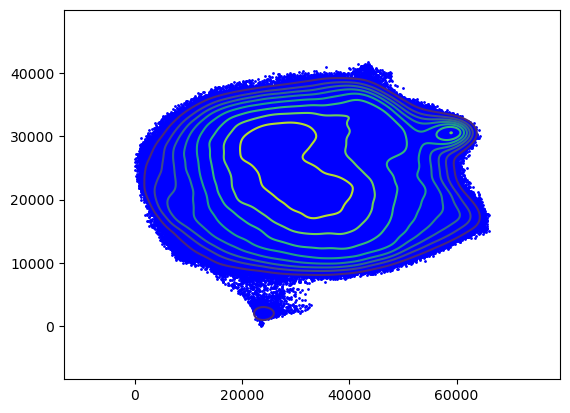

In [58]:
import numpy as np
import matplotlib.pyplot as pl
import scipy.stats as st

# data = np.random.multivariate_normal((0, 0), [[0.8, 0.05], [0.05, 0.7]], 400)
x = new_df['UMAP_X']
y = new_df['UMAP_Y']
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

# Expand the area to ensure contours are complete
xmin_expanded = xmin - (xmax - xmin) * 0.2  # 10% expansion on both sides
xmax_expanded = xmax + (xmax - xmin) * 0.2
ymin_expanded = ymin - (ymax - ymin) * 0.2
ymax_expanded = ymax + (ymax - ymin) * 0.2

# Peform the kernel density estimate with expanded area
xx, yy = np.mgrid[xmin_expanded:xmax_expanded:1024j, ymin_expanded:ymax_expanded:1024j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = st.gaussian_kde(values)
f = np.reshape(kernel(positions).T, xx.shape)
import matplotlib.contour as mcontour
fig, ax = plt.subplots()
contours = ax.contour(xx, yy, f, filled=False, levels=np.linspace(f.min(), f.max(), 10))
# plot the scatterplot of the points
plt.scatter(x, y, c='blue', s=1)
contour_lines = []
contours.allsegs
for seg in contours.allsegs:
    for line in seg:
        contour_lines.append(line.tolist())


contour_lines

In [62]:
contour_lines
# convert to json
contour_lines_json = json.dumps(contour_lines)
contour_lines_json
# save to file
with open('/Users/swarchol/Downloads/melanoma/contour.json', 'w') as f:
    json.dump(contour_lines_json, f)


In [59]:
ref_contour_path = '/Users/swarchol/Downloads/reference/contour.json'
ref_contour = json.load(open(ref_contour_path))

In [60]:
ref_contour

[[[0.0, 27120.0], [0.0, 27120.0]],
 [[17708.70702283436, 0.0],
  [17707.06451612903, 0.16627533371004036],
  [17681.513196480937, 2.9451531214725812],
  [17655.961876832844, 5.916763835225878],
  [17630.41055718475, 9.077172766608676],
  [17604.859237536657, 12.422830285764856],
  [17579.307917888564, 15.950612744578333],
  [17553.75659824047, 19.65786488342083],
  [17528.205278592373, 23.542443459714484],
  [17509.505078176757, 26.51026392961877],
  [17502.65395894428, 27.547067487181465],
  [17477.102639296187, 31.564374323866097],
  [17451.551319648093, 35.74417487948813],
  [17426.0, 40.08671770060102],
  [17400.448680351907, 44.59297311099111],
  [17374.897360703813, 49.264676439219954],
  [17355.038377467652, 53.02052785923754],
  [17349.346041055716, 54.04828659750356],
  [17323.794721407623, 58.79834244637551],
  [17298.24340175953, 63.71217243272478],
  [17272.692082111436, 68.79475834568574],
  [17247.140762463343, 74.05202759647862],
  [17221.58944281525, 79.49089454613501],